In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import pybaseball

print("Environment ready")

Environment ready


In [2]:
from pybaseball import batting_stats

In [7]:
raw_data = batting_stats(2021, 2025)

In [56]:
df = raw_data[
    ["Season", "Name", "Team", "Pos", "Age", "PA", "AVG", "OBP", "SLG", "OPS", "xBA", "K%", "Contact%", "EV", "Barrel%", "HardHit%"]]

In [57]:
# keep all players with 500+ PA's in any season
pa_filter = df[df['PA'] >= 500].copy()

print(f"Players before filter: {df['Name'].nunique()}")
print(f"Players after filter: {pa_filter['Name'].nunique()}")
print(f"Total rows: {len(pa_filter)}")

Players before filter: 286
Players after filter: 286
Total rows: 670


In [31]:
#print("Shape: ", df.shape)


In [30]:
#print(df.info())

In [29]:
#df["Name"].value_counts()

In [58]:
# sort data to ensure correct ordering
pa_filter = pa_filter.sort_values(['Name', 'Season'])

# for each player, grab their AVG from the following season
pa_filter['AVG_next'] = pa_filter.groupby('Name')['AVG'].shift(-1)

# also track what season the target belongs to (optional but useful)
pa_filter['Season_next'] = pa_filter.groupby('Name')['Season'].shift(-1)

# drop rows where next year AVG is missing (i.e. 2025 rows, or players who didn't appear next year)
model_df = pa_filter.dropna(subset=['AVG_next']).copy()

print(f"Total training rows: {len(model_df)}")
print(f"Seasons covered: {model_df['Season'].unique()}")
print(model_df[['Name', 'Season', 'AVG', 'OBP', 'SLG', 'AVG_next']].head(10))

Total training rows: 384
Seasons covered: [2021 2022 2024 2023]
                Name  Season    AVG    OBP    SLG  AVG_next
35       Aaron Judge    2021  0.287  0.373  0.544     0.311
2        Aaron Judge    2022  0.311  0.425  0.686     0.322
0        Aaron Judge    2024  0.322  0.458  0.701     0.331
255     Adam Frazier    2021  0.305  0.368  0.411     0.238
161  Adley Rutschman    2023  0.277  0.374  0.435     0.250
495    Adolis Garcia    2021  0.243  0.286  0.454     0.250
397    Adolis Garcia    2022  0.250  0.300  0.456     0.245
145    Adolis Garcia    2023  0.245  0.328  0.508     0.224
609    Adolis Garcia    2024  0.224  0.284  0.400     0.227
536        Alec Bohm    2022  0.280  0.315  0.398     0.274


In [67]:
# standardize all features - puts them on the same scale
from sklearn.preprocessing import StandardScaler

# scaler for full model (keep as is)
features_all = ['xBA', 'OBP', 'SLG', 'OPS', 'K%', 'Contact%', 'EV', 'Barrel%', 'HardHit%']
scaler_all = StandardScaler()
X = scaler_all.fit_transform(model_df[features_all])

# separate scaler for xBA only model
features_xba = ['xBA']
scaler_xba = StandardScaler()
X_xba = scaler_xba.fit_transform(model_df[features_xba])

y = model_df[target].values

#print(f"X shape: {X.shape}")
#print(f"y shape: {y.shape}")
#print(f"y mean: {y.mean():.3f}, y std: {y.std():.3f}")

In [38]:
with pm.Model() as batting_model:
    
    # --- Priors on coefficients ---
    alpha = pm.Normal('alpha', mu=0.260, sigma=0.05)  # intercept, centered on league average
    betas = pm.Normal('betas', mu=0, sigma=0.05, shape=len(features))  # one per feature
    
    # --- Model noise ---
    sigma = pm.HalfNormal('sigma', sigma=0.05)
    
    # --- Linear model ---
    mu = alpha + pm.math.dot(X, betas)
    
    # --- Likelihood ---
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)
    
    # --- Sample ---
    trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 57 seconds.


In [ ]:
print(az.summary(trace, var_names=['alpha', 'betas', 'sigma']))

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     0.260  0.001   0.258    0.263        0.0      0.0    3046.0   
betas[0]  0.011  0.002   0.008    0.015        0.0      0.0    2671.0   
betas[1] -0.003  0.003  -0.009    0.002        0.0      0.0    2459.0   
betas[2] -0.000  0.002  -0.005    0.004        0.0      0.0    2771.0   
betas[3]  0.002  0.002  -0.002    0.005        0.0      0.0    2930.0   
sigma     0.023  0.001   0.021    0.024        0.0      0.0    3341.0   

          ess_tail  r_hat  
alpha       2704.0    1.0  
betas[0]    2707.0    1.0  
betas[1]    2190.0    1.0  
betas[2]    2410.0    1.0  
betas[3]    2763.0    1.0  
sigma       2907.0    1.0  


In [41]:
for i, feature in enumerate(features):
    row = az.summary(trace, var_names=['betas']).iloc[i]
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]")

xBA           mean=+0.0110  hdi=[+0.0080, +0.0150]
K%            mean=-0.0030  hdi=[-0.0090, +0.0020]
Contact%      mean=-0.0000  hdi=[-0.0050, +0.0040]
HardHit%      mean=+0.0020  hdi=[-0.0020, +0.0050]


In [68]:
# Model 1: xBA only
features_xba = ['xBA']
X_xba = StandardScaler().fit_transform(model_df[features_xba])

with pm.Model() as model_xba:
    alpha = pm.Normal('alpha', mu=0.260, sigma=0.05)
    betas = pm.Normal('betas', mu=0, sigma=0.05, shape=len(features_xba))
    sigma = pm.HalfNormal('sigma', sigma=0.05)
    mu = alpha + pm.math.dot(X_xba, betas)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)
    trace_xba = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 64 seconds.


In [69]:
print(az.summary(trace_xba, var_names=['alpha', 'betas', 'sigma']))

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     0.260  0.001   0.258    0.263        0.0      0.0    4313.0   
betas[0]  0.013  0.001   0.011    0.015        0.0      0.0    4409.0   
sigma     0.023  0.001   0.021    0.024        0.0      0.0    3892.0   

          ess_tail  r_hat  
alpha       2913.0    1.0  
betas[0]    2965.0    1.0  
sigma       3019.0    1.0  


In [70]:
for i, feature in enumerate(features_xba):
    row = az.summary(trace_xba, var_names=['betas']).iloc[i]
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]")

xBA           mean=+0.0130  hdi=[+0.0110, +0.0150]


In [63]:
# Model 2: other model features, excluding xBA
features_no_xba = ['OPS', 'K%']
X_no_xba = StandardScaler().fit_transform(model_df[features_no_xba])

with pm.Model() as model_no_xba:
    alpha = pm.Normal('alpha', mu=0.260, sigma=0.05)
    betas = pm.Normal('betas', mu=0, sigma=0.05, shape=len(features_no_xba))
    sigma = pm.HalfNormal('sigma', sigma=0.05)
    mu = alpha + pm.math.dot(X_no_xba, betas)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)
    trace_no_xba = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 81 seconds.


In [64]:
print(az.summary(trace_no_xba, var_names=['alpha', 'betas', 'sigma']))

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     0.260  0.001   0.258    0.263        0.0      0.0    4205.0   
betas[0]  0.008  0.001   0.006    0.011        0.0      0.0    4794.0   
betas[1] -0.008  0.001  -0.010   -0.006        0.0      0.0    3910.0   
sigma     0.024  0.001   0.022    0.025        0.0      0.0    3928.0   

          ess_tail  r_hat  
alpha       2880.0    1.0  
betas[0]    3188.0    1.0  
betas[1]    2874.0    1.0  
sigma       3016.0    1.0  


In [65]:
for i, feature in enumerate(features_no_xba):
    row = az.summary(trace_no_xba, var_names=['betas']).iloc[i]
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]")

OPS           mean=+0.0080  hdi=[+0.0060, +0.0110]
K%            mean=-0.0080  hdi=[-0.0100, -0.0060]


In [71]:
# making predictions using xBA model

# get 2025 rows
df_2025 = pa_filter[pa_filter['Season'] == 2025].copy()

# standardize using the SAME scaler fitted on training data
X_2025 = scaler_xba.transform(df_2025[features_xba])

# we use scaler.transform not scaler.fit_transform here. 
# The scaler was fitted on training data and we must apply 
# the same transformation to 2025 data, otherwise the scales won't match.

print(f"Players to predict: {len(df_2025)}")
print(df_2025[['Name', 'xBA', 'AVG']].head(10))

Players to predict: 145
                 Name    xBA    AVG
1         Aaron Judge  0.300  0.331
426    Addison Barger  0.255  0.243
637     Adolis Garcia  0.232  0.227
584   Agustin Ramirez  0.259  0.231
418         Alec Bohm  0.275  0.287
214     Alec Burleson  0.272  0.290
307    Alejandro Kirk  0.278  0.282
543  Andrew McCutchen  0.258  0.239
333        Andy Pages  0.258  0.272
635     Anthony Volpe  0.223  0.212


In [72]:
with model_xba:
    pm.set_data({})
    posterior_pred = pm.sample_posterior_predictive(
        trace_xba,
        var_names=['y_obs']
    )

Sampling: [y_obs]


Output()

In [73]:
# extract posterior samples of alpha, betas, sigma from trace
alpha_samples = trace_xba.posterior['alpha'].values.flatten()  # shape [4000]
beta_samples = trace_xba.posterior['betas'].values.reshape(-1, 1)  # shape [4000, 1]

# generate predictions for 2025 players
# X_2025 shape is [n_players, 1]
# result shape will be [4000, n_players]
mu_samples = alpha_samples[:, None] + (beta_samples * X_2025.T)

# summarize
df_2025['predicted_AVG'] = mu_samples.mean(axis=0)
df_2025['pred_hdi_low'] = np.percentile(mu_samples, 3, axis=0)
df_2025['pred_hdi_high'] = np.percentile(mu_samples, 97, axis=0)

print(df_2025[['Name', 'xBA', 'AVG', 'predicted_AVG', 'pred_hdi_low', 'pred_hdi_high']]
      .sort_values('predicted_AVG', ascending=False)
      .head(20))

                      Name    xBA    AVG  predicted_AVG  pred_hdi_low  \
1              Aaron Judge  0.300  0.331       0.286035      0.281262   
85   Vladimir Guerrero Jr.  0.300  0.292       0.286035      0.281262   
116            Bo Bichette  0.295  0.311       0.282995      0.278633   
400           Nico Hoerner  0.292  0.297       0.281171      0.277090   
18         George Springer  0.291  0.309       0.280563      0.276565   
34               Juan Soto  0.288  0.263       0.278740      0.274964   
505            Luis Arraez  0.287  0.292       0.278132      0.274445   
94              Yandy Diaz  0.286  0.300       0.277524      0.273890   
119         Bobby Witt Jr.  0.285  0.295       0.276916      0.273369   
46             Ketel Marte  0.285  0.283       0.276916      0.273369   
121           Jose Ramirez  0.284  0.283       0.276308      0.272821   
129               Ben Rice  0.283  0.255       0.275700      0.272315   
594        Luis Garcia Jr.  0.281  0.252       0.27

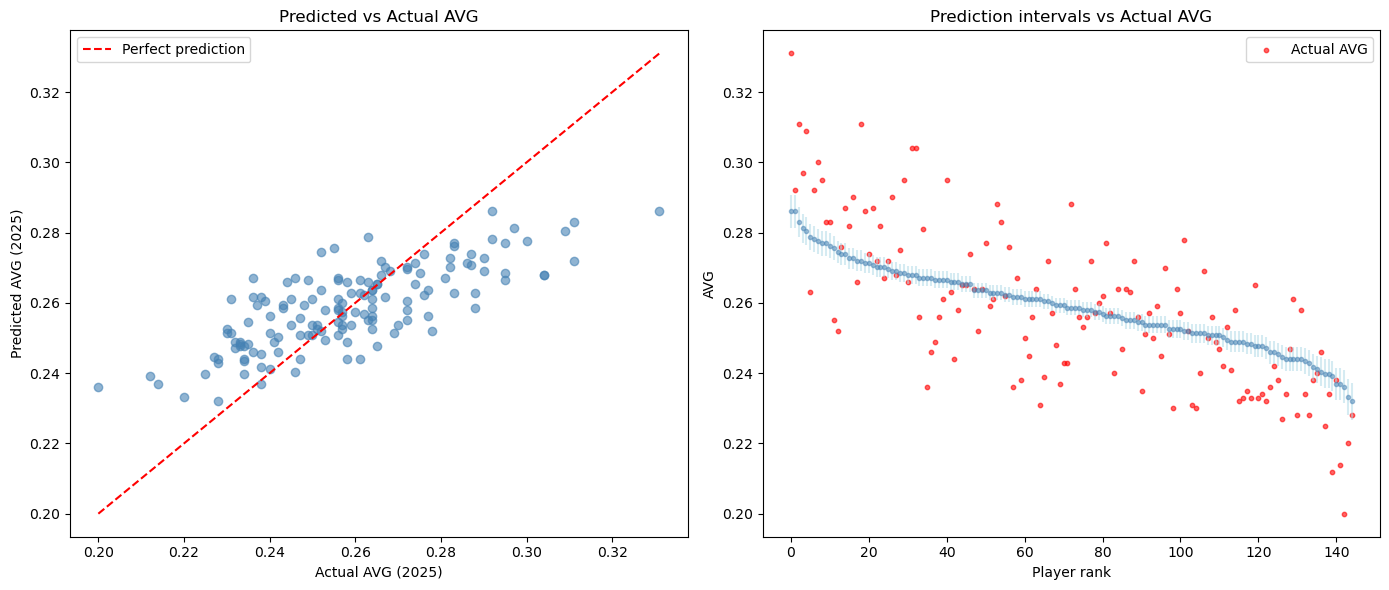

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Scatter plot of predicted vs actual AVG ---
ax = axes[0]
ax.scatter(df_2025['AVG'], df_2025['predicted_AVG'], alpha=0.6, color='steelblue')

# perfect prediction line
min_val = min(df_2025['AVG'].min(), df_2025['predicted_AVG'].min())
max_val = max(df_2025['AVG'].max(), df_2025['predicted_AVG'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')

ax.set_xlabel('Actual AVG (2025)')
ax.set_ylabel('Predicted AVG (2025)')
ax.set_title('Predicted vs Actual AVG')
ax.legend()

# --- Plot 2: Prediction intervals sorted by predicted AVG ---
ax = axes[1]
df_sorted = df_2025.sort_values('predicted_AVG', ascending=False).reset_index(drop=True)

ax.errorbar(
    range(len(df_sorted)),
    df_sorted['predicted_AVG'],
    yerr=[
        df_sorted['predicted_AVG'] - df_sorted['pred_hdi_low'],
        df_sorted['pred_hdi_high'] - df_sorted['predicted_AVG']
    ],
    fmt='o', markersize=3, alpha=0.5, color='steelblue', ecolor='lightblue'
)
ax.scatter(range(len(df_sorted)), df_sorted['AVG'], color='red', s=10, alpha=0.6, label='Actual AVG')
ax.set_xlabel('Player rank')
ax.set_ylabel('AVG')
ax.set_title('Prediction intervals vs Actual AVG')
ax.legend()

plt.tight_layout()
plt.show()

In [76]:
with pm.Model() as model_xba_v2:
    X_data = pm.Data('X_data', X_xba)
    y_data = pm.Data('y_data', y)
    
    alpha = pm.Normal('alpha', mu=0.260, sigma=0.026)  # empirical Bayes prior (exactly the sample distribution)
    betas = pm.Normal('betas', mu=0, sigma=0.1, shape=1) # losened sigma to improve coverage
    sigma = pm.HalfNormal('sigma', sigma=0.1) # losened sigma to improve coverage
    
    mu = alpha + X_data[:, 0] * betas[0]  # broadcasting
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)
    
    trace_xba_v2 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 62 seconds.


In [77]:
for i, feature in enumerate(features_xba):
    row = az.summary(trace_xba_v2, var_names=['betas']).iloc[i]
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]")

print(az.summary(trace_xba_v2, var_names=['alpha', 'sigma']))

xBA           mean=+0.0130  hdi=[+0.0110, +0.0150]
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.260  0.001   0.258    0.263        0.0      0.0    4439.0    3119.0   
sigma  0.023  0.001   0.021    0.024        0.0      0.0    4165.0    3373.0   

       r_hat  
alpha    1.0  
sigma    1.0  


In [78]:
# swap in 2025 data
with model_xba_v2:
    pm.set_data({
        'X_data': X_2025,
        'y_data': np.zeros(len(X_2025))  # dummy y
    })
    ppc_2025 = pm.sample_posterior_predictive(trace_xba_v2)

# extract predictions
pred_samples = ppc_2025.posterior_predictive['y_obs'].values.reshape(-1, len(df_2025))

df_2025['predicted_AVG'] = pred_samples.mean(axis=0)
df_2025['pred_hdi_low'] = np.percentile(pred_samples, 3, axis=0)
df_2025['pred_hdi_high'] = np.percentile(pred_samples, 97, axis=0)

# print top 20
print(df_2025[['Name', 'xBA', 'AVG', 'predicted_AVG', 'pred_hdi_low', 'pred_hdi_high']]
      .sort_values('predicted_AVG', ascending=False)
      .head(20))

Sampling: [y_obs]


Output()

                      Name    xBA    AVG  predicted_AVG  pred_hdi_low  \
85   Vladimir Guerrero Jr.  0.300  0.292       0.286252      0.242815   
1              Aaron Judge  0.300  0.331       0.286074      0.243218   
116            Bo Bichette  0.295  0.311       0.282776      0.240029   
400           Nico Hoerner  0.292  0.297       0.281069      0.238613   
18         George Springer  0.291  0.309       0.280803      0.237350   
34               Juan Soto  0.288  0.263       0.278211      0.234218   
505            Luis Arraez  0.287  0.292       0.277719      0.232389   
119         Bobby Witt Jr.  0.285  0.295       0.277373      0.233481   
94              Yandy Diaz  0.286  0.300       0.277368      0.234046   
46             Ketel Marte  0.285  0.283       0.276936      0.233728   
121           Jose Ramirez  0.284  0.283       0.276374      0.232250   
129               Ben Rice  0.283  0.255       0.275714      0.231942   
594        Luis Garcia Jr.  0.281  0.252       0.27

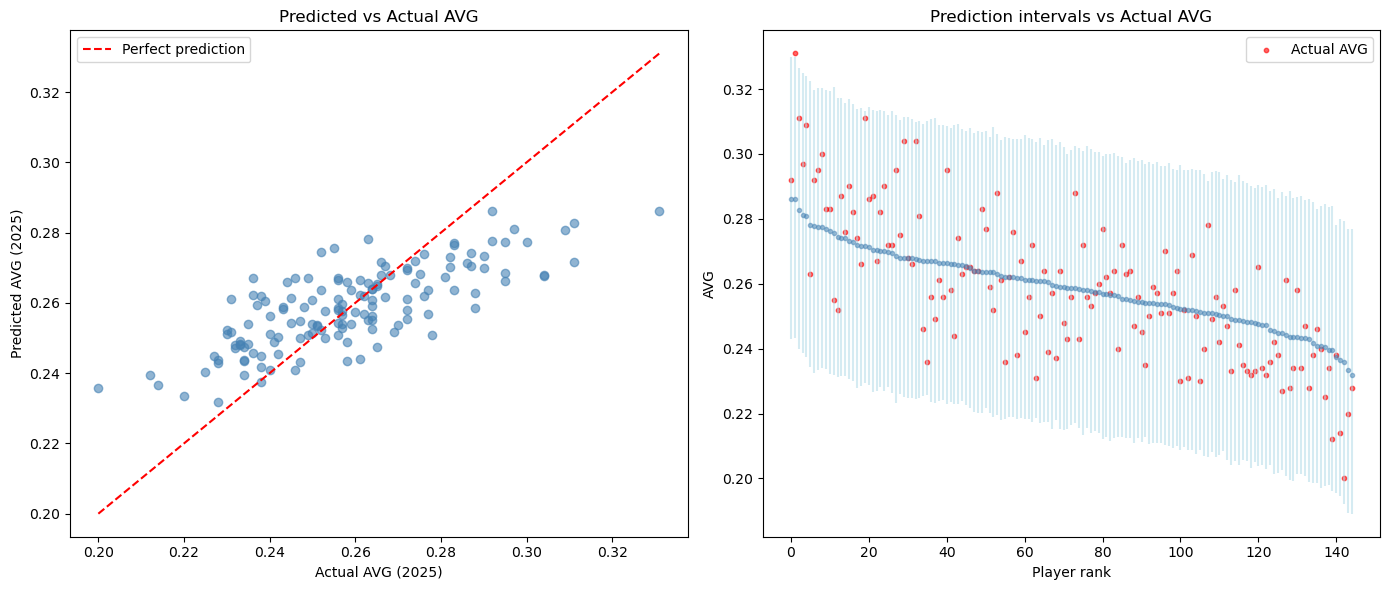

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted vs Actual
ax = axes[0]
ax.scatter(df_2025['AVG'], df_2025['predicted_AVG'], alpha=0.6, color='steelblue')
min_val = min(df_2025['AVG'].min(), df_2025['predicted_AVG'].min())
max_val = max(df_2025['AVG'].max(), df_2025['predicted_AVG'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual AVG (2025)')
ax.set_ylabel('Predicted AVG (2025)')
ax.set_title('Predicted vs Actual AVG')
ax.legend()

# Plot 2: Prediction intervals
ax = axes[1]
df_sorted = df_2025.sort_values('predicted_AVG', ascending=False).reset_index(drop=True)
ax.errorbar(range(len(df_sorted)), df_sorted['predicted_AVG'],
    yerr=[df_sorted['predicted_AVG'] - df_sorted['pred_hdi_low'],
          df_sorted['pred_hdi_high'] - df_sorted['predicted_AVG']],
    fmt='o', markersize=3, alpha=0.5, color='steelblue', ecolor='lightblue')
ax.scatter(range(len(df_sorted)), df_sorted['AVG'], color='red', s=10, alpha=0.6, label='Actual AVG')
ax.set_xlabel('Player rank')
ax.set_ylabel('AVG')
ax.set_title('Prediction intervals vs Actual AVG')
ax.legend()

plt.tight_layout()
plt.show()